# 4 - Chord Analysis

In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [7]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

In [8]:
metadata = g.load_metadata()
metadata = metadata.dropna(subset=['recording_year'])
metadata = g.load_keys(metadata)

In [9]:
major_metadata = metadata[metadata['key'].str.contains('major', na=False)]
minor_metadata = metadata[metadata['key'].str.contains('minor', na=False)]

In [10]:
major_notes = g.load_notes(major_metadata) 
minor_notes = g.load_notes(minor_metadata) 

In [11]:
note_major_count = major_notes[['note']].value_counts().reset_index()
note_major_count.columns = ['note', 'count']
note_M = note_major_count.iloc[0:10]['note'].tolist()


note_minor_count = minor_notes[['note']].value_counts().reset_index()
note_minor_count.columns = ['note', 'count']
note_m = note_minor_count.iloc[0:10]['note'].tolist()


In [13]:
notes_M_subset = major_notes[major_notes['note'].isin(note_M)].copy()
notes_m_subset = minor_notes[minor_notes['note'].isin(note_m)].copy()


In [14]:
label_major_count = notes_M_subset[['label']].value_counts().reset_index()
label_M = label_major_count.iloc[0:10]['label'].tolist()

label_minor_count = notes_m_subset[['label']].value_counts().reset_index()
label_m = label_minor_count.iloc[0:10]['label'].tolist()

In [15]:
M_notes_labels = notes_M_subset[notes_M_subset['label'].isin(label_M)]

m_notes_labels = notes_m_subset[notes_m_subset['label'].isin(label_m)]

In [16]:
def notes_count(note_df, x, zero=False):
    result = []
    for i, label in enumerate(x):
        subset = note_df[note_df['label'] == label]

        if subset.empty:
            if zero:
                count = 0
            else:
                count = 0.000000000000000000000001

        else:
            count = subset.iloc[0]['count']
            
        result.append(count)
    return np.array(result)
       

In [21]:
bins = [1940, 1960, 1980, 2000, 2020]
bin_labels = ['1940-1960', '1960-1980', '1980-2000', '2000-2020']

M_notes_labels['recording_year'] = pd.to_numeric(M_notes_labels['recording_year'], errors='coerce')
M_notes_labels['year_bin'] = pd.cut(M_notes_labels['recording_year'], bins=bins, labels=bin_labels, right=False)

m_notes_labels['recording_year'] = pd.to_numeric(m_notes_labels['recording_year'], errors='coerce')
m_notes_labels['year_bin'] = pd.cut(m_notes_labels['recording_year'], bins=bins, labels=bin_labels, right=False)

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_91890/3126868345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  M_notes_labels['recording_year'] = pd.to_numeric(M_notes_labels['recording_year'], errors='coerce')
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_91890/3126868345.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  M_notes_labels['year_bin'] = pd.cut(M_notes_labels['recording_year'], bins=bins, labels=bin_labels, right=False)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c000

1940-1960: snum: [2770 3553  926  672  875 1221  836  465  467  210]
1960-1980: snum: [1882 1241  971  185  700  364  254  848  528  134]
1980-2000: snum: [ 651  403  101 1273  383  165  621   87  100  548]
2000-2020: snum: [1058  507 1002  453  528  675  508  737  545  739]


/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_91890/98624787.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_91890/98624787.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_91890/98624787.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_91890/98624787.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)


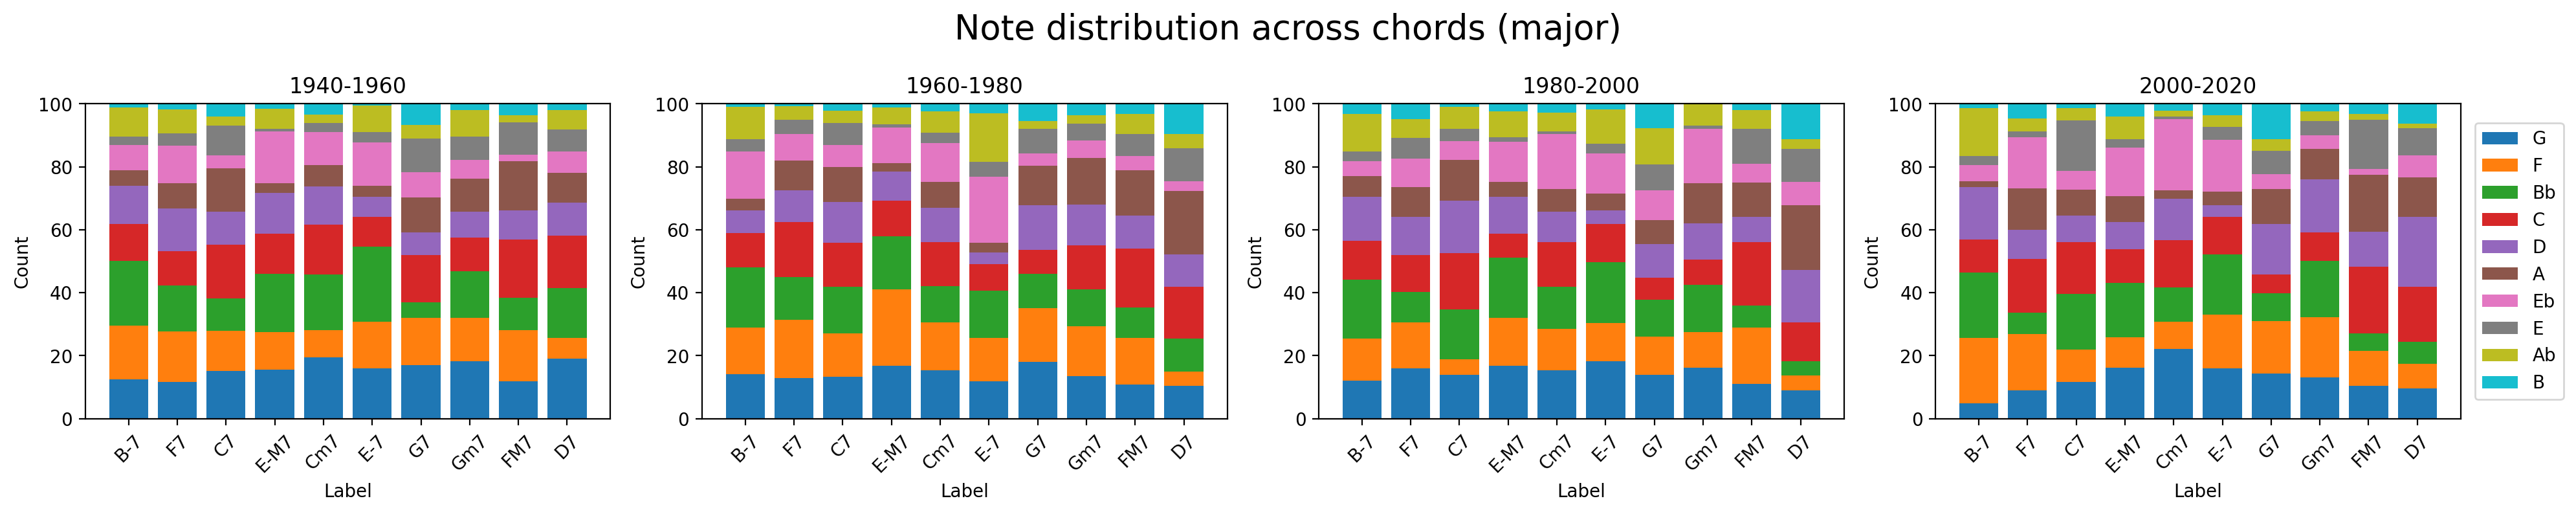

In [57]:
num_bins = len(bin_labels)
x = label_M

fig, axes = plt.subplots(1, num_bins, figsize=(5 * num_bins, 4))

for ax, years in zip(axes, bin_labels):
    M_notes_year = M_notes_labels[M_notes_labels['year_bin']== years]
    M_notes_year_grouped = M_notes_year.groupby(by=['label', 'note']).size().reset_index(name='count')
    
    tot_notes = M_notes_year.groupby(by=['label']).size().reset_index(name='count')
    snum = notes_count(tot_notes, x, zero=True)
    snum = np.array(snum)
    print(f"{years}: snum: {snum}")

    current_itn = np.zeros(len(note_M))
    for note in note_M:
        subset_notes = M_notes_year_grouped[M_notes_year_grouped['note'] == note]
        y = notes_count(subset_notes, x)
        y = 100 * y / snum
    
        ax.bar(x, y, bottom = current_itn, label=note)
    
        current_itn = current_itn + y

    ax.set_title(f"{years}")
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.set_xticklabels(x,rotation=45)
    ax.set_ylim(0, 100)  # or whatever your consistent max value is
    ax.set_yticks(np.arange(0, 120, step=20))

plt.suptitle('Note distribution across chords (major)', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()
    

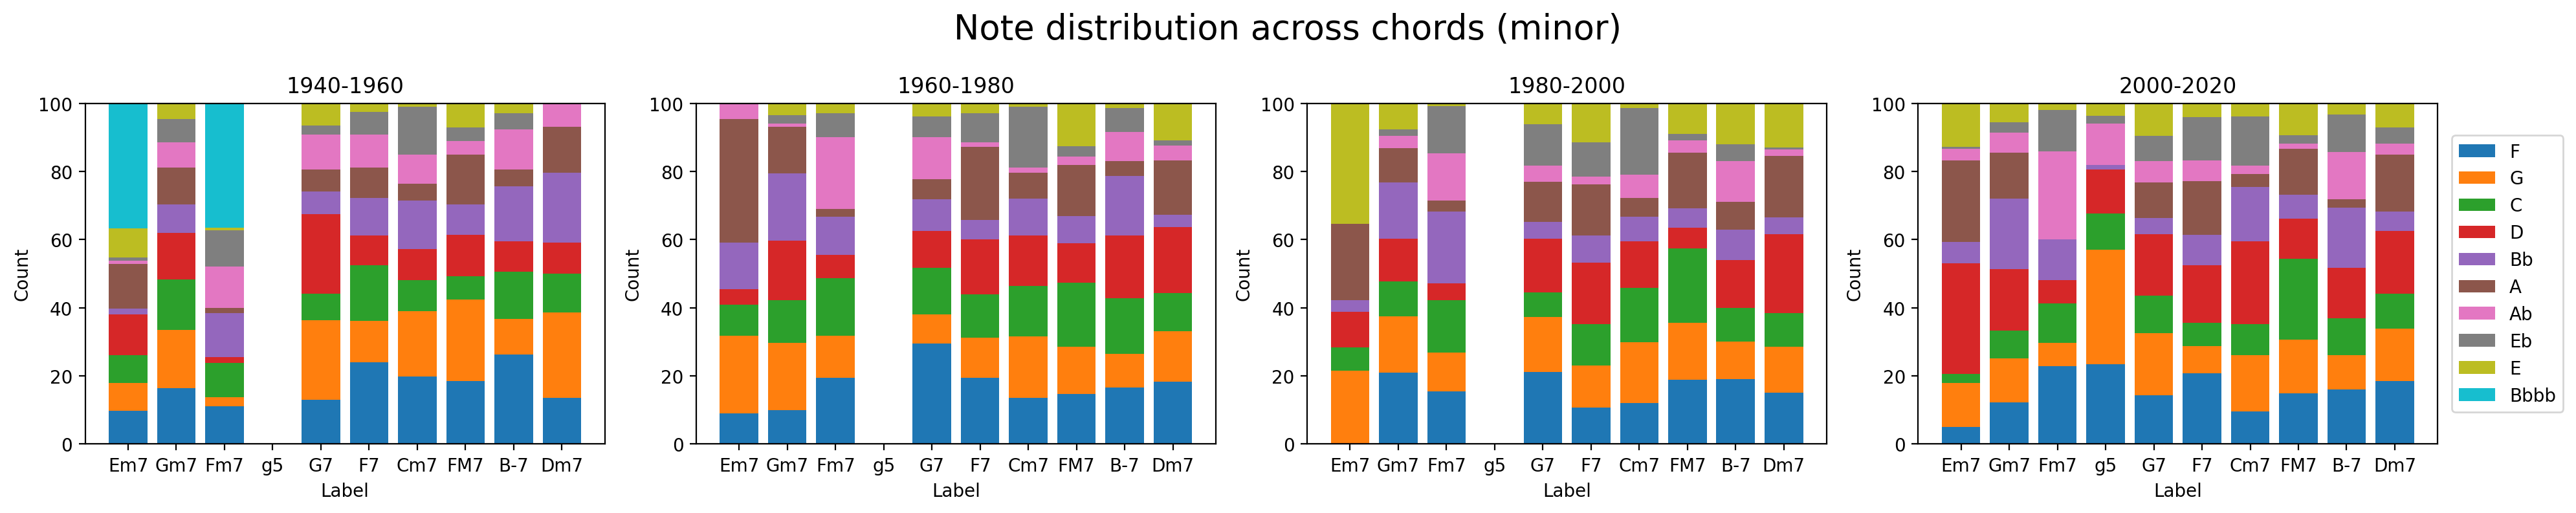

In [59]:
num_bins = len(bin_labels)
x = label_m

fig, axes = plt.subplots(1, num_bins, figsize=(5 * num_bins, 4))

for ax, years in zip(axes, bin_labels):
    m_notes_year = m_notes_labels[m_notes_labels['year_bin']== years]
    m_notes_year_grouped = m_notes_year.groupby(by=['label', 'note']).size().reset_index(name='count')
    
    tot_notes = m_notes_year.groupby(by=['label']).size().reset_index(name='count')
    snum = notes_count(tot_notes, x, zero=False)
    snum = np.array(snum)

    current_itn = np.zeros(len(note_m))
    for note in note_m:
        subset_notes = m_notes_year_grouped[m_notes_year_grouped['note'] == note]
        y = notes_count(subset_notes, x, zero=True)
        y = 100 * y / snum
    
        ax.bar(x, y, bottom = current_itn, label=note)
    
        current_itn = current_itn + y

    ax.set_title(f"{years}")
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    
plt.suptitle('Note distribution across chords (minor)', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.savefig(f"../Results/NotesPerChordMinor")
plt.show()